Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|█████████████████████████████████████████████████████████████████████████████████| 528M/528M [00:01<00:00, 310MB/s]


Using image: intel_dataset/Intel-Image-Classification/test/buildings/20057.jpg
Predicted Class: bell cote


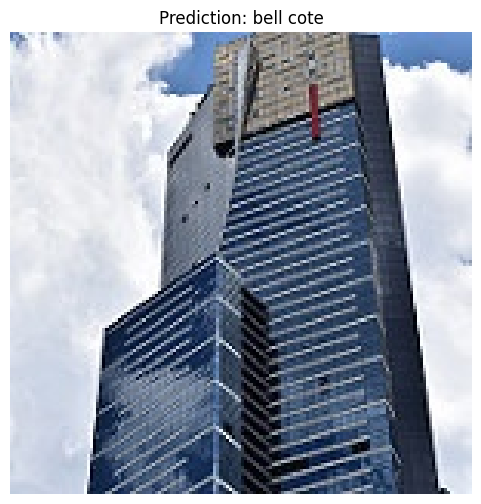

In [1]:
# Install once if needed:
# !pip install torch torchvision pillow matplotlib

import os
import zipfile
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.models import vgg16, VGG16_Weights

# ==========================
# Extract Dataset
# ==========================
zip_path = "archive.zip"      # Change if needed
extract_path = "intel_dataset"

if os.path.exists(zip_path) and not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

# ==========================
# Load Pretrained VGG16
# ==========================
weights = VGG16_Weights.DEFAULT
model = vgg16(weights=weights)
model.eval()

preprocess = weights.transforms()

# ==========================
# Find First Image
# ==========================
image_path = None

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(root, file)
            break
    if image_path:
        break

if image_path is None:
    raise FileNotFoundError("No image found in dataset.")

print("Using image:", image_path)

# ==========================
# Load Image
# ==========================
image = Image.open(image_path).convert("RGB")

# ==========================
# Preprocess & Predict
# ==========================
input_tensor = preprocess(image).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)

pred_idx = torch.argmax(output, dim=1).item()
label = weights.meta["categories"][pred_idx]

print("Predicted Class:", label)

# ==========================
# Show Image
# ==========================
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title(f"Prediction: {label}")
plt.axis("off")
plt.show()